## Importing Data:

In [5]:
import pandas as pd

train_path = '/kaggle/input/competitions/playground-series-s6e3/train.csv'
test_path = '/kaggle/input/competitions/playground-series-s6e3/test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print('Train Shape:', train_df.shape)
display(train_df.head(3))
print('Test Shape:', test_df.shape)
display(test_df.head(3))

Train Shape: (594194, 21)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35,No


Test Shape: (254655, 20)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55


In [6]:
target = 'Churn'

cat_cols = ['gender','Partner', 'Dependents', 'SeniorCitizen',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',] 

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [7]:
train_df[target] = train_df[target].map({'No': 0, 'Yes': 1})

## Feature Engineering:

In [8]:
combined_df = pd.concat([train_df,test_df], axis=0, ignore_index=True)

### Digit Decomposition:
It breaks numeric values into individual digits and uses each digit as a separate feature. This technique is sometimes used in tree models.

This will be applied to the num_cols

In [9]:
import numpy as np

digit_cols = []

for col in num_cols:
    max_val = combined_df[col].abs().max()

    #conditional 1:
    if max_val == 0:
        digit_count = 1
    else:
      digit_count = int(np.log10(max_val)) + 1  

    for i in range(digit_count):
        new_col = f"{col}_digit_pos_{i+1}"

        combined_df[new_col] = (combined_df[col] // (10**i)) % 10
        combined_df[new_col] = combined_df[new_col].astype(int)

        digit_cols.append(new_col)

    #conditional 2:
    if combined_df[col].dtype == 'float64':
        max_dec_count = 2

        if (combined_df[col] % 1 != 0).any():
            for i in range(1, max_dec_count + 1):
                new_col = f"{col}_digit_dec_{i}"
                
                combined_df[new_col] = (combined_df[col] * (10**i)).round().astype(int) % 10
                
                digit_cols.append(new_col)

In [10]:
print('Newly created digit_cols are as follows: \n',digit_cols)

Newly created digit_cols are as follows: 
 ['tenure_digit_pos_1', 'tenure_digit_pos_2', 'MonthlyCharges_digit_pos_1', 'MonthlyCharges_digit_pos_2', 'MonthlyCharges_digit_pos_3', 'MonthlyCharges_digit_dec_1', 'MonthlyCharges_digit_dec_2', 'TotalCharges_digit_pos_1', 'TotalCharges_digit_pos_2', 'TotalCharges_digit_pos_3', 'TotalCharges_digit_pos_4', 'TotalCharges_digit_dec_1', 'TotalCharges_digit_dec_2']


**Explaination**:
* **Conditional 1:**
      Seperates the digits before decimal point into diffrent columns on the basisi of there respective positioning.
* **Conditional 2:**
      Does the same thing but for the digits after the decimal point.

I tried adding features like:
* Binning
* GroupMean Encoding
* Freq Encoding
But they were adding more noise than helping get closer to good predictions, so they were kept on halt and not used alongside digit decomposition.

In [11]:
for col in cat_cols:
    combined_df[col] = combined_df[col].astype(str).astype('category')

In [12]:
train_df = combined_df.iloc[: len(train_df)].reset_index(drop=True)
test_df  = combined_df.iloc[len(train_df) :].reset_index(drop=True)

## Optuna Tuning:

In [13]:
features = cat_cols + num_cols + digit_cols

In [14]:
X = train_df[features]
y = train_df[target]

X_test = test_df[features]

In [15]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        # Core learning parameters
        "n_estimators": trial.suggest_int("n_estimators", 500, 3500),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        
        # Tree complexity control
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        
        # Sampling 
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0),
        
        # Regularization 
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),

        # Performance
        "random_state": 42,
        "eval_metric": "logloss",
        "tree_method": "hist",   
        "verbosity": 0,
        "device":'cuda',
        "enable_categorical":True
    }

    model = XGBClassifier(**params)

    score = cross_val_score(model, X, y, cv=5, scoring='roc_auc').mean()

    return score

In [16]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=65)

[I 2026-03-07 08:11:57,194] A new study created in memory with name: no-name-177be275-848c-42e8-9969-4c932944fbe2
[I 2026-03-07 08:12:26,130] Trial 0 finished with value: 0.9154761019956602 and parameters: {'n_estimators': 531, 'learning_rate': 0.01169369253276995, 'max_depth': 7, 'min_child_weight': 3, 'gamma': 0.46644236209033296, 'subsample': 0.6774674537198473, 'colsample_bytree': 0.8273965258102562, 'reg_alpha': 0.026549187839774266, 'reg_lambda': 0.0001608844787951308}. Best is trial 0 with value: 0.9154761019956602.
[I 2026-03-07 08:13:24,265] Trial 1 finished with value: 0.9169897479178161 and parameters: {'n_estimators': 3150, 'learning_rate': 0.02514491965142829, 'max_depth': 3, 'min_child_weight': 5, 'gamma': 2.348048150312523, 'subsample': 0.688914679490295, 'colsample_bytree': 0.8060452564239271, 'reg_alpha': 0.0007044314486484711, 'reg_lambda': 1.1107735753231114e-05}. Best is trial 1 with value: 0.9169897479178161.
[I 2026-03-07 08:14:40,017] Trial 2 finished with value:

In [17]:
print(study.best_params)
print(study.best_value)

{'n_estimators': 2500, 'learning_rate': 0.021343076630791043, 'max_depth': 6, 'min_child_weight': 7, 'gamma': 0.861751498622332, 'subsample': 0.8551145690799331, 'colsample_bytree': 0.6623034984700539, 'reg_alpha': 0.019334069196449158, 'reg_lambda': 6.572714277172166}
0.9179758298561163


* **best_params_set** = {'n_estimators': 2500, 'learning_rate': 0.021343076630791043, 'max_depth': 6, 'min_child_weight': 7, 'gamma': 0.861751498622332, 'subsample': 0.8551145690799331, 'colsample_bytree': 0.6623034984700539, 'reg_alpha': 0.019334069196449158, 'reg_lambda': 6.572714277172166}
* **best_score** = 0.9179758298561163

## Checking Feature Importance:
Training a model on full training data to get an idea about which features are contributing the most, also to check if out newly created features are useful or not.

In [18]:
model = XGBClassifier(
    **study.best_params,
    random_state= 42,
    eval_metric= "logloss",
    tree_method= "hist",   
    verbosity= 0,
    device= 'cuda',
    enable_categorical= True
)

model.fit(X,y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6623034984700539, device='cuda',
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=0.861751498622332, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.021343076630791043,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=7, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2500, n_jobs=None,
              num_parallel_tree=None, ...)

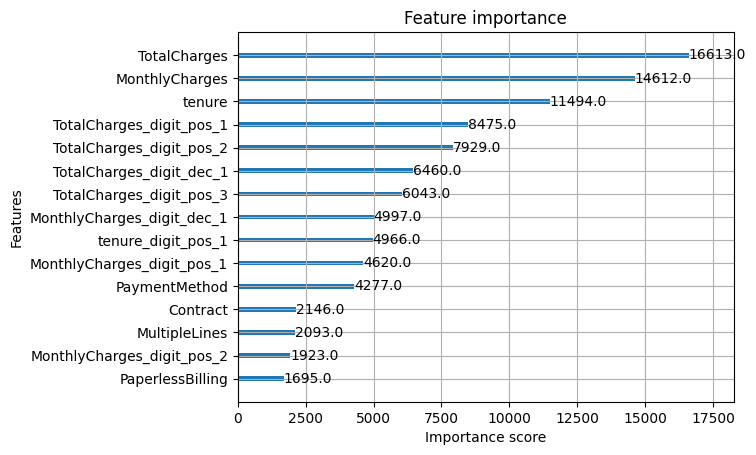

In [21]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model, max_num_features=15)
plt.show()

From the above graph we can conclude that our newly created features are surely being used and arent adding noise.

In [25]:
y_pred = model.predict_proba(X_test)[:,1]

In [26]:
submission = pd.DataFrame({
    'id': test_df['id'],
    target: y_pred 
})

submission.to_csv('submission.csv', index= False)